In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

In [4]:
df = pd.read_csv("cpu_utilization_asg_misconfiguration.csv")
df.head()

,timestamp,value
0,2014-05-14 01:14:00,85.835
1,2014-05-14 01:19:00,88.167
2,2014-05-14 01:24:00,44.595
3,2014-05-14 01:29:00,56.282
4,2014-05-14 01:34:00,36.534


In [5]:
df.shape

(18050, 2)

In [6]:
df.isna() # no missing values

,timestamp,value
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
18045,False,False
18046,False,False
18047,False,False
18048,False,False


In [7]:
df.describe()

,value
count,18050.000000
mean,38.282756
std,15.639294
min,11.529000
25%,30.789000
50%,32.001000
75%,35.660500
max,100.000000


From the get-go, this usage is much lower and more controlled, but there was at least one instance where a computer got throttled.

In [8]:
Q3 = df["value"].quantile(0.75)
Q1 = df["value"].quantile(0.25)
IQR = Q3 - Q1
upperBound = Q3 + 1.5 * IQR
print(len(df[df["value"] > upperBound]))
print(f"{len(df[df["value"] > upperBound]) / 18050 * 100:.1f} % outliers above Q3 suggests many anomalies")

4149
23.0 % outliers above Q3 suggests many anomalies


Aggregate early on since we have >18000 values

In [24]:
# perhaps keep 2 rolling avgs in case we need smth more granular
df["6h_avg"] = df["value"].rolling(window=72).mean()
df["1d_avg"] = df["value"].rolling(window=288).mean()

df["1d_sd"] = df["value"].rolling(window=288).std()

df["lower1SD"] = df["1d_avg"] - (1 * df["1d_sd"])
df["upper1SD"] = df["1d_avg"] + (1 * df["1d_sd"])

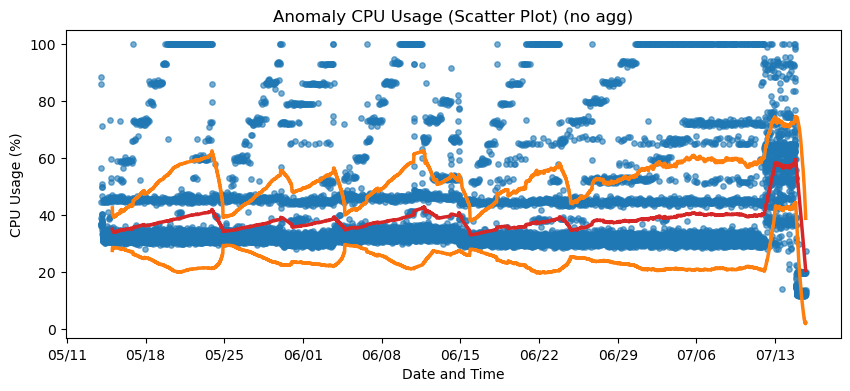

In [26]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

# line chart
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.scatter(
    df["timestamp"], df["value"], color="tab:blue",
    alpha=0.6, 
s=15
)
ax1.set_title("Anomaly CPU Usage (Scatter Plot) (no agg)")
ax1.set_xlabel("Date and Time")
ax1.set_ylabel("CPU Usage (%)")

ax1.plot(
   df["timestamp"],
   df["1d_avg"],
   color="tab:red",
   linewidth=2.5,
   label="Unagg Rolling Avg" 
)

ax1.plot(
   df["timestamp"],
   df["lower1SD"],
   color="tab:orange",
   linewidth=2.5,
   label="Unagg Rolling Avg" 
)

ax1.plot(
   df["timestamp"],
   df["upper1SD"],
   color="tab:orange",
   linewidth=2.5,
   label="Unagg Rolling Avg" 
)



ax1.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))



Interesting how there is a huge cluster, like normal running for a majority but throughout weeks there are instances where it climbs up.
I'll try aggregating per hour over the 06/01 to 06/29 window, and using agg max instead of agg mean since the first try kept silencing the throttled values

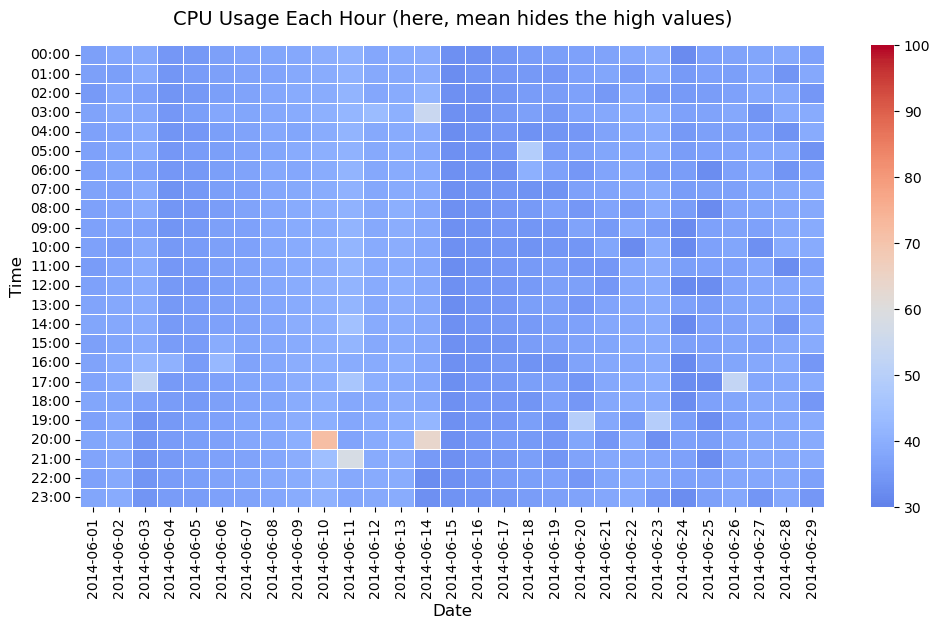

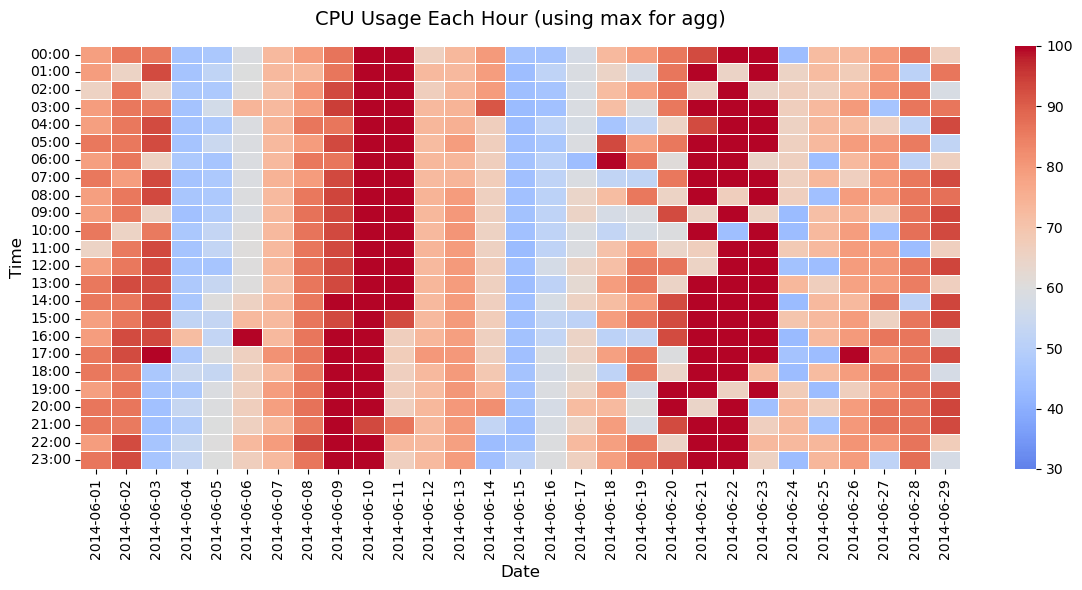

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# filter dates
start_date = "2014-06-01 00:04:00"
end_date = "2014-06-29 23:59:00"
df_flat = df[(df["timestamp"] >= start_date) & (df["timestamp"] <= end_date)].copy()

df_flat["timestamp"] = pd.to_datetime(df_flat["timestamp"])
df_flat["timestamp_h"] = df_flat["timestamp"].dt.floor("1h")

df_flat["Date"] = df_flat["timestamp_h"].dt.date
df_flat["Time"] = df_flat["timestamp_h"].dt.strftime("%H:%M")

# 3. Pivot table using df_flat (where 'Time', 'Date', and 'value' exist)
df_pivotedMax = df_flat.pivot_table(
    index="Time", columns="Date", values="value", aggfunc="max"
)
df_pivotedMean = df_flat.pivot_table(
    index="Time", columns="Date", values="value", aggfunc="mean"
)

# 4. Heatmap plot
fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.heatmap(
    df_pivotedMean, cmap="coolwarm", linewidths=0.5, vmin=30, vmax=100, center=60, ax=ax2
)


ax2.set_title("CPU Usage Each Hour (here, mean hides the high values)", fontsize=14, pad=15)
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Time", fontsize=12)
ax2.set_facecolor("gray")

fig3, ax3 = plt.subplots(figsize=(12, 6))
sns.heatmap(
    df_pivotedMax, cmap="coolwarm", linewidths=0.5, vmin=30, vmax=100, center=60, ax=ax3
)


ax3.set_title("CPU Usage Each Hour (using max for agg)", fontsize=14, pad=15)
ax3.set_xlabel("Date", fontsize=12)
ax3.set_ylabel("Time", fontsize=12)
ax3.set_facecolor("gray")

plt.tight_layout()
plt.show()

It appears that there have been 5 major periods in which CPU usage spiked. Instance #2 (05/18 to 06/01) appears to be two smaller spikes, while the last instance (06/29 to 07/13) took longer to resolve before usage took a significant dip.

This exercise, unlike the first one, provided a good visual for me to see why we might prefer rolling averages and standard deviations over mean/sd of just the entire dataset, since a lot of the anomalies were masked by the frequently lower values.

This also marked my decision to use max for the agg function for the heatmap since I knew the values in the 30s would drag down the observations in the 90s, and I wanted to see how high it was getting each hour for the June time period I confined the data to keep the heatmap readable.